In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.metrics import accuracy_score, confusion_matrix

In [2]:

df = pd.read_csv("ipl (1).csv")

df.head()

,mid,date,venue,bat_team,bowl_team,batsman,bowler,runs,wickets,overs,runs_last_5,wickets_last_5,striker,non-striker,total
0,1,2008-04-18,M Chinnaswamy Stadium,Kolkata Knight Riders,Royal Challengers Bangalore,SC Ganguly,P Kumar,1,0,0.1,1,0,0,0,222
1,1,2008-04-18,M Chinnaswamy Stadium,Kolkata Knight Riders,Royal Challengers Bangalore,BB McCullum,P Kumar,1,0,0.2,1,0,0,0,222
2,1,2008-04-18,M Chinnaswamy Stadium,Kolkata Knight Riders,Royal Challengers Bangalore,BB McCullum,P Kumar,2,0,0.2,2,0,0,0,222
3,1,2008-04-18,M Chinnaswamy Stadium,Kolkata Knight Riders,Royal Challengers Bangalore,BB McCullum,P Kumar,2,0,0.3,2,0,0,0,222
4,1,2008-04-18,M Chinnaswamy Stadium,Kolkata Knight Riders,Royal Challengers Bangalore,BB McCullum,P Kumar,2,0,0.4,2,0,0,0,222


In [3]:
df.head()

,mid,date,venue,bat_team,bowl_team,batsman,bowler,runs,wickets,overs,runs_last_5,wickets_last_5,striker,non-striker,total
0,1,2008-04-18,M Chinnaswamy Stadium,Kolkata Knight Riders,Royal Challengers Bangalore,SC Ganguly,P Kumar,1,0,0.1,1,0,0,0,222
1,1,2008-04-18,M Chinnaswamy Stadium,Kolkata Knight Riders,Royal Challengers Bangalore,BB McCullum,P Kumar,1,0,0.2,1,0,0,0,222
2,1,2008-04-18,M Chinnaswamy Stadium,Kolkata Knight Riders,Royal Challengers Bangalore,BB McCullum,P Kumar,2,0,0.2,2,0,0,0,222
3,1,2008-04-18,M Chinnaswamy Stadium,Kolkata Knight Riders,Royal Challengers Bangalore,BB McCullum,P Kumar,2,0,0.3,2,0,0,0,222
4,1,2008-04-18,M Chinnaswamy Stadium,Kolkata Knight Riders,Royal Challengers Bangalore,BB McCullum,P Kumar,2,0,0.4,2,0,0,0,222


In [4]:
df.tail()

,mid,date,venue,bat_team,bowl_team,batsman,bowler,runs,wickets,overs,runs_last_5,wickets_last_5,striker,non-striker,total
76009,617,2017-05-21,"Rajiv Gandhi International Stadium, Uppal",Mumbai Indians,Rising Pune Supergiant,KH Pandya,DT Christian,121,7,19.2,40,0,40,12,129
76010,617,2017-05-21,"Rajiv Gandhi International Stadium, Uppal",Mumbai Indians,Rising Pune Supergiant,KH Pandya,DT Christian,127,7,19.3,46,0,46,12,129
76011,617,2017-05-21,"Rajiv Gandhi International Stadium, Uppal",Mumbai Indians,Rising Pune Supergiant,KH Pandya,DT Christian,128,7,19.4,47,0,47,12,129
76012,617,2017-05-21,"Rajiv Gandhi International Stadium, Uppal",Mumbai Indians,Rising Pune Supergiant,MG Johnson,DT Christian,129,7,19.5,48,0,47,13,129
76013,617,2017-05-21,"Rajiv Gandhi International Stadium, Uppal",Mumbai Indians,Rising Pune Supergiant,KH Pandya,DT Christian,129,8,19.6,47,1,47,13,129


In [5]:
df.shape

(76014, 15)

In [6]:
df.columns

Index(['mid', 'date', 'venue', 'bat_team', 'bowl_team', 'batsman', 'bowler',
       'runs', 'wickets', 'overs', 'runs_last_5', 'wickets_last_5', 'striker',
       'non-striker', 'total'],
      dtype='object')

In [7]:
df.dtypes

mid                 int64
date               object
venue              object
bat_team           object
bowl_team          object
batsman            object
bowler             object
runs                int64
wickets             int64
overs             float64
runs_last_5         int64
wickets_last_5      int64
striker             int64
non-striker         int64
total               int64
dtype: object

In [8]:

quantitative_columns = df.select_dtypes(include=['int64','float64']).columns


qualitative_columns = df.select_dtypes(include=['object']).columns

print("Quantitative Columns:")
print(quantitative_columns)

print("\nQualitative Columns:")
print(qualitative_columns)

Quantitative Columns:
Index(['mid', 'runs', 'wickets', 'overs', 'runs_last_5', 'wickets_last_5',
       'striker', 'non-striker', 'total'],
      dtype='object')

Qualitative Columns:
Index(['date', 'venue', 'bat_team', 'bowl_team', 'batsman', 'bowler'], dtype='object')


In [9]:

discrete = ['runs','wickets','runs_last_5','wickets_last_5','total']


continuous = ['overs']


nominal = ['venue','bat_team','bowl_team','batsman','bowler']

print("Discrete Variables:", discrete)
print("Continuous Variables:", continuous)
print("Nominal Variables:", nominal)

Discrete Variables: ['runs', 'wickets', 'runs_last_5', 'wickets_last_5', 'total']
Continuous Variables: ['overs']
Nominal Variables: ['venue', 'bat_team', 'bowl_team', 'batsman', 'bowler']


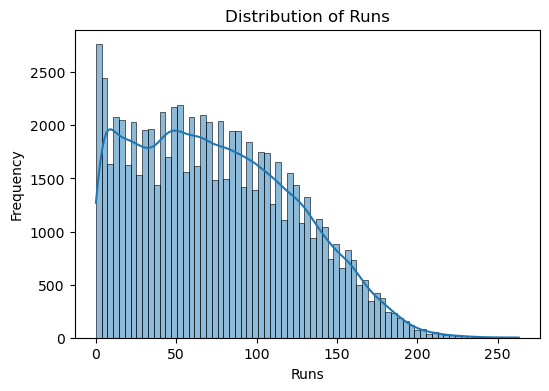

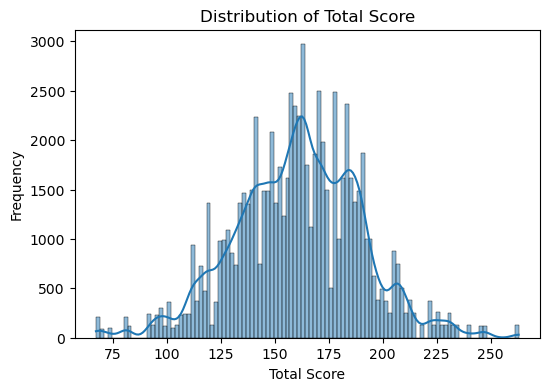

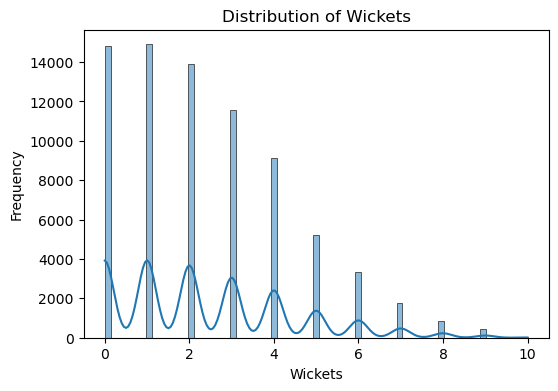

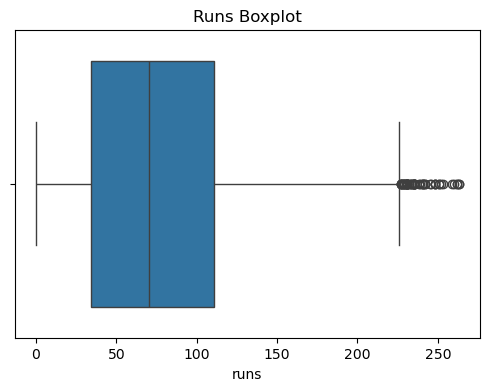

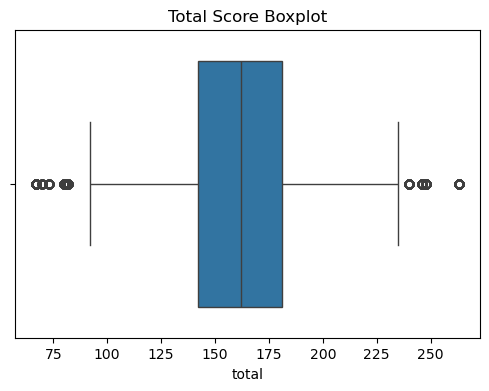

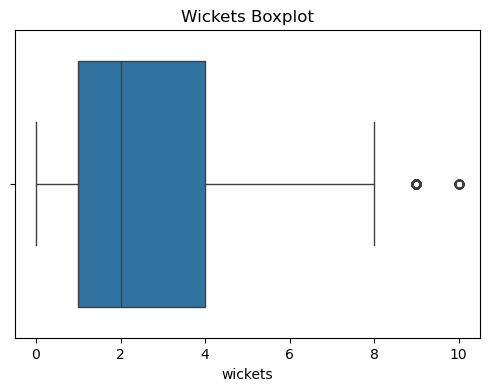

In [10]:

plt.figure(figsize=(6,4))
sns.histplot(df['runs'], kde=True)
plt.title("Distribution of Runs")
plt.xlabel("Runs")
plt.ylabel("Frequency")
plt.show()


plt.figure(figsize=(6,4))
sns.histplot(df['total'], kde=True)
plt.title("Distribution of Total Score")
plt.xlabel("Total Score")
plt.ylabel("Frequency")
plt.show()


plt.figure(figsize=(6,4))
sns.histplot(df['wickets'], kde=True)
plt.title("Distribution of Wickets")
plt.xlabel("Wickets")
plt.ylabel("Frequency")
plt.show()



plt.figure(figsize=(6,4))
sns.boxplot(x=df['runs'])
plt.title("Runs Boxplot")
plt.show()

plt.figure(figsize=(6,4))
sns.boxplot(x=df['total'])
plt.title("Total Score Boxplot")
plt.show()

plt.figure(figsize=(6,4))
sns.boxplot(x=df['wickets'])
plt.title("Wickets Boxplot")
plt.show()

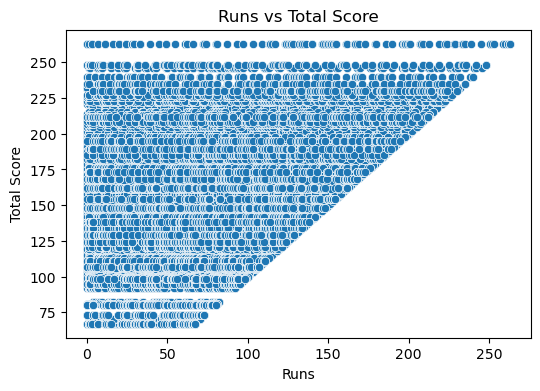

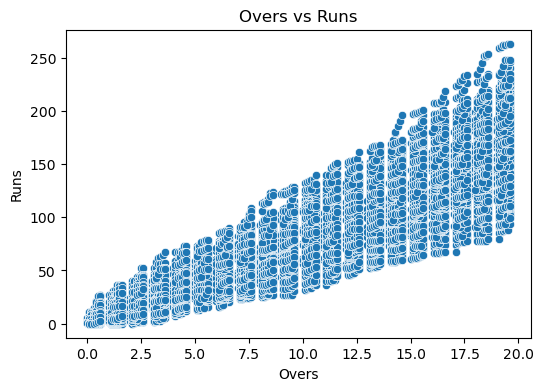

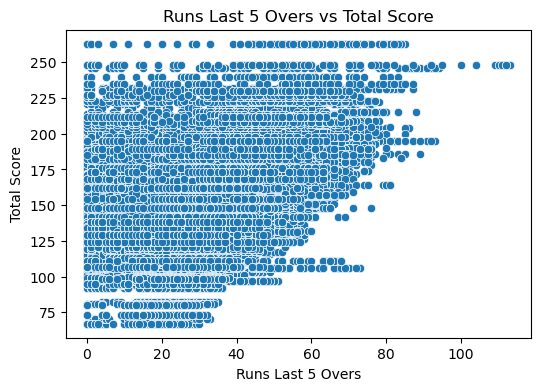

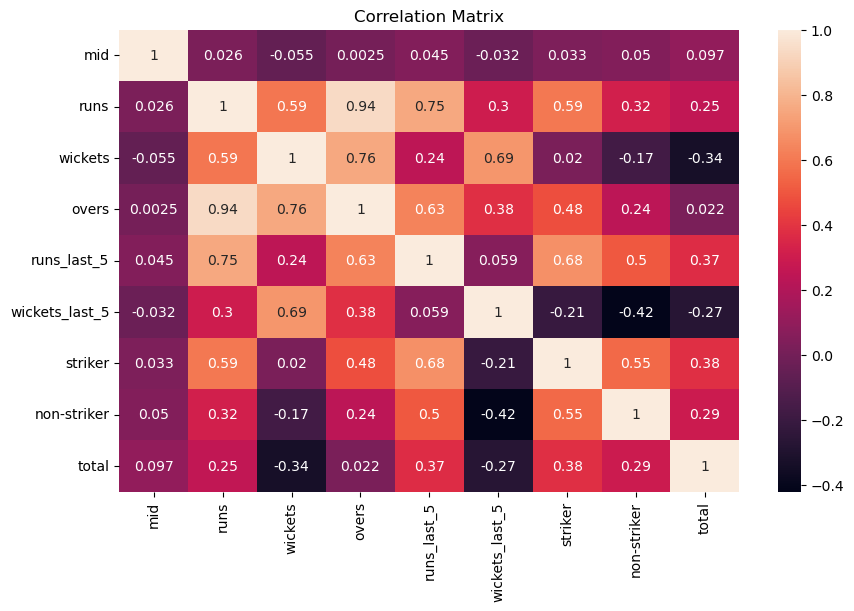

In [11]:

plt.figure(figsize=(6,4))
sns.scatterplot(x=df['runs'], y=df['total'])
plt.title("Runs vs Total Score")
plt.xlabel("Runs")
plt.ylabel("Total Score")
plt.show()


plt.figure(figsize=(6,4))
sns.scatterplot(x=df['overs'], y=df['runs'])
plt.title("Overs vs Runs")
plt.xlabel("Overs")
plt.ylabel("Runs")
plt.show()


plt.figure(figsize=(6,4))
sns.scatterplot(x=df['runs_last_5'], y=df['total'])
plt.title("Runs Last 5 Overs vs Total Score")
plt.xlabel("Runs Last 5 Overs")
plt.ylabel("Total Score")
plt.show()



plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), annot=True)
plt.title("Correlation Matrix")
plt.show()

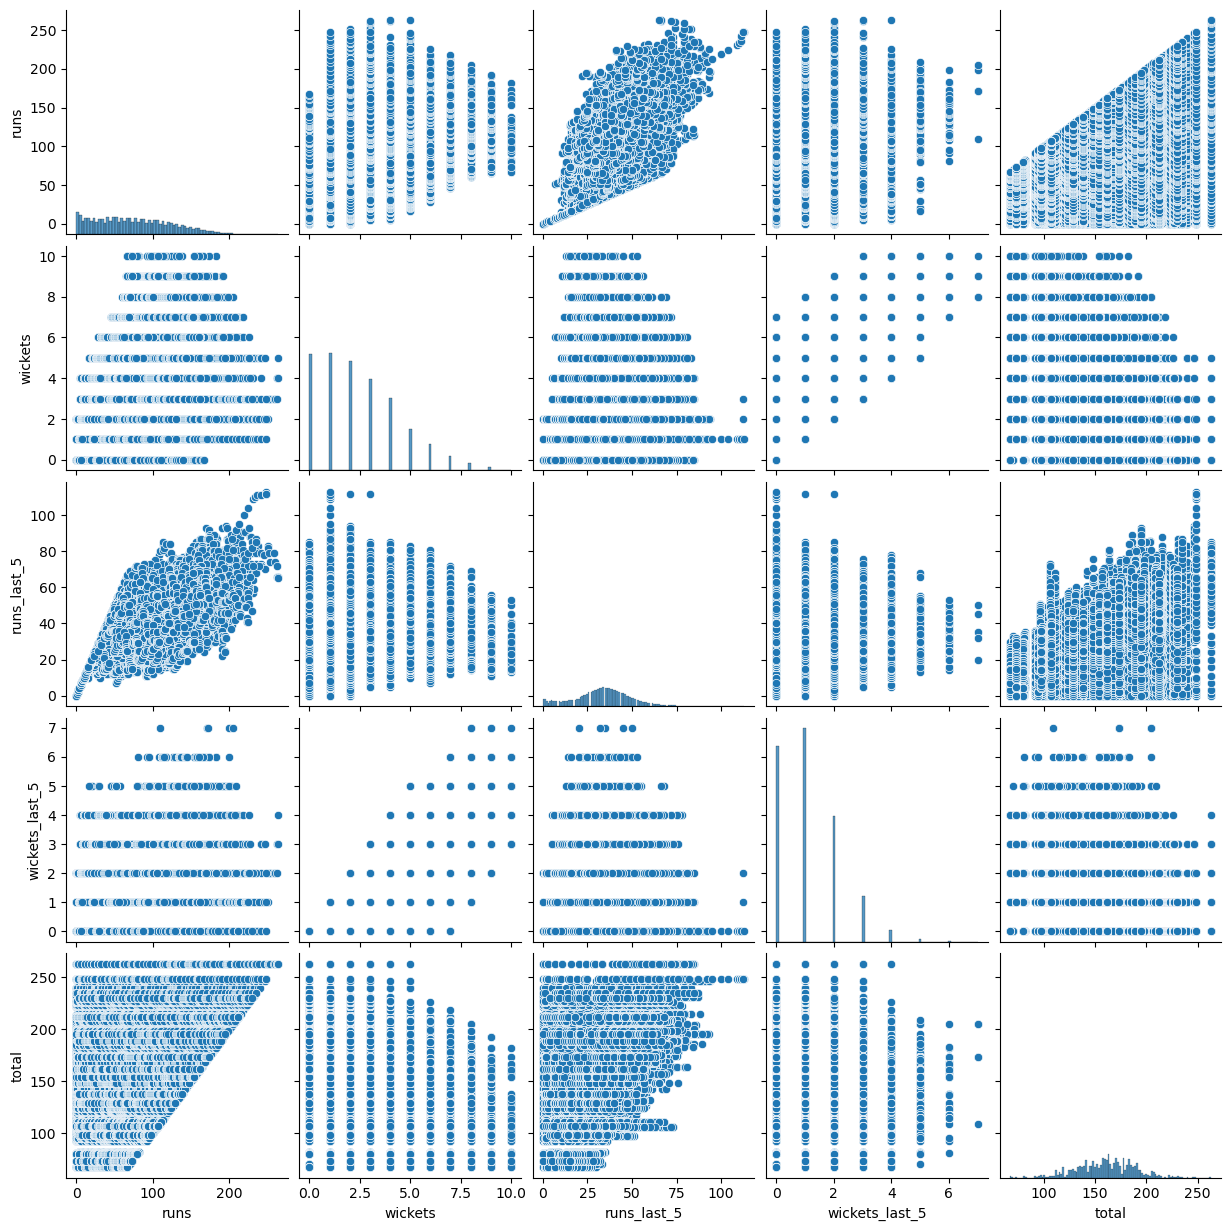

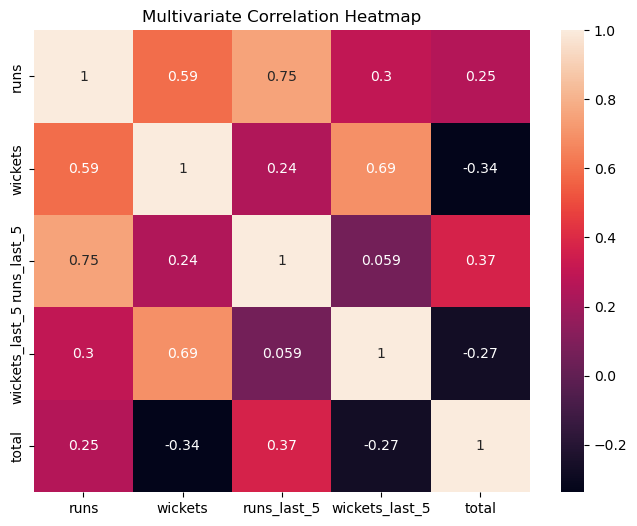

In [12]:


sns.pairplot(df[['runs','wickets','runs_last_5','wickets_last_5','total']])
plt.show()



plt.figure(figsize=(8,6))
sns.heatmap(
    df[['runs','wickets','runs_last_5','wickets_last_5','total']].corr(),
    annot=True
)

plt.title("Multivariate Correlation Heatmap")
plt.show()

In [13]:
 # missing values

 df.isnull().sum()

mid               0
date              0
venue             0
bat_team          0
bowl_team         0
batsman           0
bowler            0
runs              0
wickets           0
overs             0
runs_last_5       0
wickets_last_5    0
striker           0
non-striker       0
total             0
dtype: int64

In [14]:
df.fillna(df.mean(numeric_only=True), inplace=True)

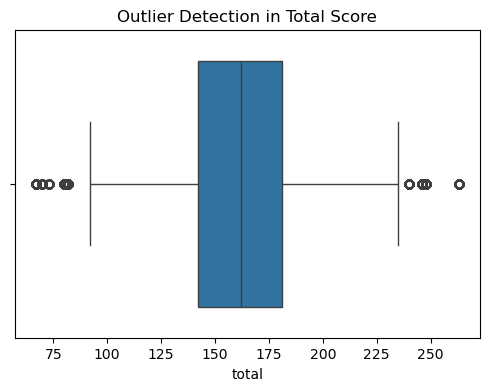

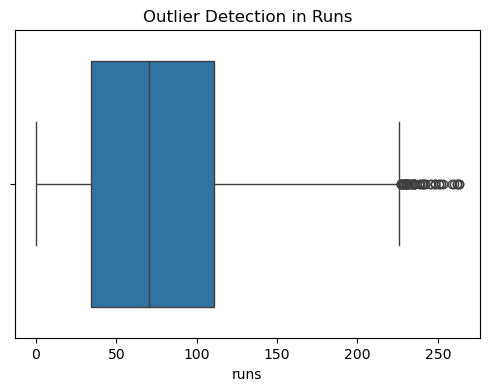

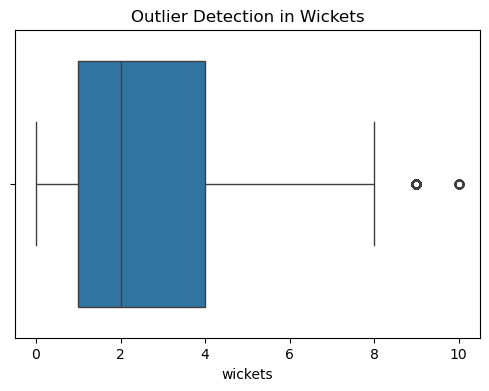

In [15]:
plt.figure(figsize=(6,4))
sns.boxplot(x=df['total'])
plt.title("Outlier Detection in Total Score")
plt.show()

plt.figure(figsize=(6,4))
sns.boxplot(x=df['runs'])
plt.title("Outlier Detection in Runs")
plt.show()

plt.figure(figsize=(6,4))
sns.boxplot(x=df['wickets'])
plt.title("Outlier Detection in Wickets")
plt.show()

In [16]:
print("Mean of Total Score:", df['total'].mean())
print("Median of Total Score:", df['total'].median())

print("\nIf mean and median difference is high, outliers may exist.")

Mean of Total Score: 160.9014523640382
Median of Total Score: 162.0

If mean and median difference is high, outliers may exist.


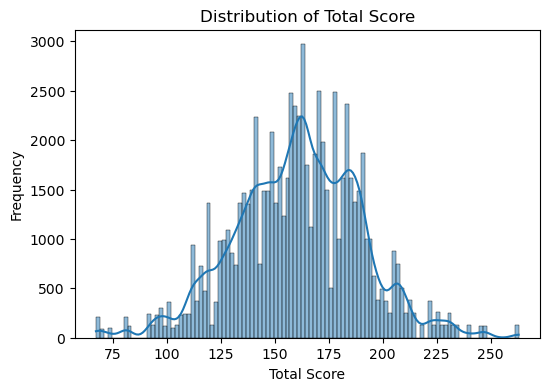

In [17]:
plt.figure(figsize=(6,4))
sns.histplot(df['total'], kde=True)

plt.title("Distribution of Total Score")
plt.xlabel("Total Score")
plt.ylabel("Frequency")

plt.show()

In [18]:
df['total'].mean()

np.float64(160.9014523640382)

In [19]:
df['total'].median()

162.0

In [20]:
df['total'].std()

29.24623082629794

In [21]:
df['total'].skew()

np.float64(-0.06026792976238969)

In [22]:
df['total'].kurtosis()

np.float64(0.40727271162233025)

In [23]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 76014 entries, 0 to 76013
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   mid             76014 non-null  int64  
 1   date            76014 non-null  object 
 2   venue           76014 non-null  object 
 3   bat_team        76014 non-null  object 
 4   bowl_team       76014 non-null  object 
 5   batsman         76014 non-null  object 
 6   bowler          76014 non-null  object 
 7   runs            76014 non-null  int64  
 8   wickets         76014 non-null  int64  
 9   overs           76014 non-null  float64
 10  runs_last_5     76014 non-null  int64  
 11  wickets_last_5  76014 non-null  int64  
 12  striker         76014 non-null  int64  
 13  non-striker     76014 non-null  int64  
 14  total           76014 non-null  int64  
dtypes: float64(1), int64(8), object(6)
memory usage: 8.7+ MB


In [24]:
df.describe()

,mid,runs,wickets,overs,runs_last_5,wickets_last_5,striker,non-striker,total
count,76014.000000,76014.000000,76014.000000,76014.000000,76014.000000,76014.000000,76014.000000,76014.000000,76014.000000
mean,308.627740,74.889349,2.415844,9.783068,33.216434,1.120307,24.962283,8.869287,160.901452
std,178.156878,48.823327,2.015207,5.772587,14.914174,1.053343,20.079752,10.795742,29.246231
min,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,67.000000
25%,154.000000,34.000000,1.000000,4.600000,24.000000,0.000000,10.000000,1.000000,142.000000
50%,308.000000,70.000000,2.000000,9.600000,34.000000,1.000000,20.000000,5.000000,162.000000
75%,463.000000,111.000000,4.000000,14.600000,43.000000,2.000000,35.000000,13.000000,181.000000
max,617.000000,263.000000,10.000000,19.600000,113.000000,7.000000,175.000000,109.000000,263.000000


In [25]:

df.isnull().sum()

mid               0
date              0
venue             0
bat_team          0
bowl_team         0
batsman           0
bowler            0
runs              0
wickets           0
overs             0
runs_last_5       0
wickets_last_5    0
striker           0
non-striker       0
total             0
dtype: int64

In [26]:
df.corr(numeric_only=True)

,mid,runs,wickets,overs,runs_last_5,wickets_last_5,striker,non-striker,total
mid,1.000000,0.026470,-0.055220,0.002487,0.045320,-0.031886,0.033432,0.049975,0.096586
runs,0.026470,1.000000,0.591007,0.938154,0.750565,0.297768,0.594818,0.315422,0.254498
wickets,-0.055220,0.591007,1.000000,0.755240,0.242942,0.693740,0.019712,-0.171962,-0.337343
overs,0.002487,0.938154,0.755240,1.000000,0.629374,0.382850,0.477508,0.236430,0.022282
runs_last_5,0.045320,0.750565,0.242942,0.629374,1.000000,0.058672,0.675924,0.501475,0.368253
wickets_last_5,-0.031886,0.297768,0.693740,0.382850,0.058672,1.000000,-0.214576,-0.421250,-0.273475
striker,0.033432,0.594818,0.019712,0.477508,0.675924,-0.214576,1.000000,0.554439,0.381664
non-striker,0.049975,0.315422,-0.171962,0.236430,0.501475,-0.421250,0.554439,1.000000,0.293233
total,0.096586,0.254498,-0.337343,0.022282,0.368253,-0.273475,0.381664,0.293233,1.000000


In [27]:

X = df[['runs','wickets','overs','runs_last_5','wickets_last_5']]


y = df['total']

print("Independent Variables:")
print(X.columns)

print("\nDependent Variable:")
print("total")

Independent Variables:
Index(['runs', 'wickets', 'overs', 'runs_last_5', 'wickets_last_5'], dtype='object')

Dependent Variable:
total


In [28]:
X.head()

,runs,wickets,overs,runs_last_5,wickets_last_5
0,1,0,0.1,1,0
1,1,0,0.2,1,0
2,2,0,0.2,2,0
3,2,0,0.3,2,0
4,2,0,0.4,2,0


In [29]:

y.head()

0    222
1    222
2    222
3    222
4    222
Name: total, dtype: int64

In [30]:
covariance = np.cov(df['runs'], df['total'])
covariance

array([[2383.71728937,  363.39764403],
       [ 363.39764403,  855.34201755]])

In [31]:
df[['runs','wickets','overs','runs_last_5','wickets_last_5','total']].corr()

,runs,wickets,overs,runs_last_5,wickets_last_5,total
runs,1.000000,0.591007,0.938154,0.750565,0.297768,0.254498
wickets,0.591007,1.000000,0.755240,0.242942,0.693740,-0.337343
overs,0.938154,0.755240,1.000000,0.629374,0.382850,0.022282
runs_last_5,0.750565,0.242942,0.629374,1.000000,0.058672,0.368253
wickets_last_5,0.297768,0.693740,0.382850,0.058672,1.000000,-0.273475
total,0.254498,-0.337343,0.022282,0.368253,-0.273475,1.000000


In [32]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [33]:
X_train.shape
X_test.shape

(15203, 5)

In [34]:
model = LinearRegression()

In [35]:
model.fit(X_train, y_train)

LinearRegression()

In [36]:
predictions = model.predict(X_test)

print("Predicted Values:")
print(predictions[:10])

Predicted Values:
[142.24619472 185.49204982 139.56374401 161.94926098 158.82020037
 143.9431075  174.75954731 163.85780346 163.30223209 156.89876118]


In [37]:
comparison = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": predictions
})

comparison.head()

,Actual,Predicted
0,134,142.246195
1,195,185.492050
2,183,139.563744
3,183,161.949261
4,193,158.820200


In [38]:
train_pred = model.predict(X_train)

train_mse = mean_squared_error(y_train, train_pred)
train_r2 = r2_score(y_train, train_pred)

print("Training MSE:", train_mse)
print("Training R2 Score:", train_r2)

Training MSE: 425.74733124604836
Training R2 Score: 0.5039502016813333


In [39]:
test_pred = model.predict(X_test)

test_mse = mean_squared_error(y_test, test_pred)
test_r2 = r2_score(y_test, test_pred)

print("Testing MSE:", test_mse)
print("Testing R2 Score:", test_r2)

Testing MSE: 404.150603094508
Testing R2 Score: 0.5208599136090356


In [40]:
df['high_score'] = np.where(df['total'] > 160, 1, 0)

df[['total','high_score']].head()

,total,high_score
0,222,1
1,222,1
2,222,1
3,222,1
4,222,1


In [41]:
X_class = df[['runs','wickets','overs','runs_last_5','wickets_last_5']]
y_class = df['high_score']

X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_class,
    y_class,
    test_size=0.2,
    random_state=42
)

print("Training Data:", X_train_c.shape)
print("Testing Data:", X_test_c.shape)

Training Data: (60811, 5)
Testing Data: (15203, 5)


In [42]:
log_model = LogisticRegression(max_iter=1000)

log_model.fit(X_train_c, y_train_c)

LogisticRegression(max_iter=1000)

In [43]:
pred_class = log_model.predict(X_test_c)

print("Predicted Values:")
print(pred_class[:10])

Predicted Values:
[0 1 0 1 0 0 1 1 1 0]


In [44]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test_c, pred_class)

print("Model Accuracy:", accuracy)

Model Accuracy: 0.7685325264750378


In [45]:
mse = mean_squared_error(y_test, predictions)

print("Mean Squared Error (MSE):", mse)

Mean Squared Error (MSE): 404.150603094508


In [46]:
mae = mean_absolute_error(y_test, predictions)

print("Mean Absolute Error (MAE):", mae)

Mean Absolute Error (MAE): 14.840532380739024


In [47]:
r2 = r2_score(y_test, predictions)

print("R2 Score:", r2)

R2 Score: 0.5208599136090356


In [48]:
print("Model Evaluation Interpretation:")

print("Lower MSE and MAE indicate better model performance.")

print("R2 Score close to 1 means the model explains the data well.")

print("If R2 Score is close to 0, the model performance is poor.")

Model Evaluation Interpretation:
Lower MSE and MAE indicate better model performance.
R2 Score close to 1 means the model explains the data well.
If R2 Score is close to 0, the model performance is poor.


In [49]:
mse = mean_squared_error(y_test, predictions)
mae = mean_absolute_error(y_test, predictions)
r2 = r2_score(y_test, predictions)

print("Mean Squared Error (MSE):", mse)
print("Mean Absolute Error (MAE):", mae)
print("R2 Score:", r2)

Mean Squared Error (MSE): 404.150603094508
Mean Absolute Error (MAE): 14.840532380739024
R2 Score: 0.5208599136090356


In [50]:
results = pd.DataFrame({
    "Metric": ["MSE", "MAE", "R2 Score"],
    "Value": [mse, mae, r2]
})

results

,Metric,Value
0,MSE,404.150603
1,MAE,14.840532
2,R2 Score,0.520860


Text(0, 0.5, 'Values')

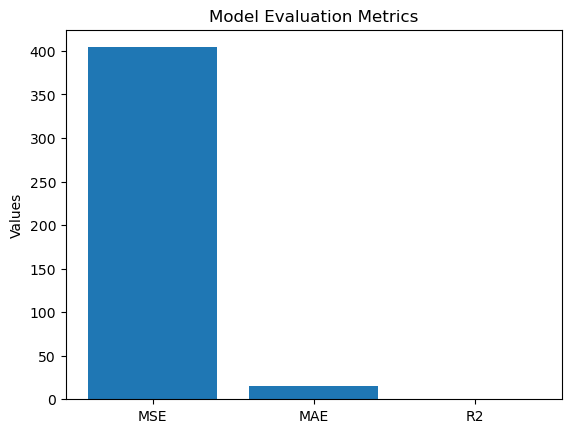

In [51]:

metrics = ["MSE", "MAE", "R2"]
values = [mse, mae, r2]

plt.bar(metrics, values)

plt.title("Model Evaluation Metrics")
plt.ylabel("Values")

In [52]:
print("Model Evaluation Interpretation:")

print("1. Lower MSE indicates better prediction accuracy.")

print("2. Lower MAE means smaller average prediction error.")

print("3. R2 Score close to 1 indicates a good regression model.")

Model Evaluation Interpretation:
1. Lower MSE indicates better prediction accuracy.
2. Lower MAE means smaller average prediction error.
3. R2 Score close to 1 indicates a good regression model.


Text(0, 0.5, 'Frequency')

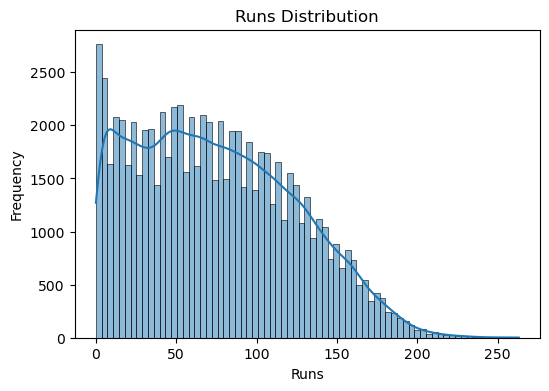

In [53]:
plt.figure(figsize=(6,4))
sns.histplot(df['runs'], kde=True)

plt.title("Runs Distribution")
plt.xlabel("Runs")
plt.ylabel("Frequency")

Text(0.5, 1.0, 'Total Score Boxplot')

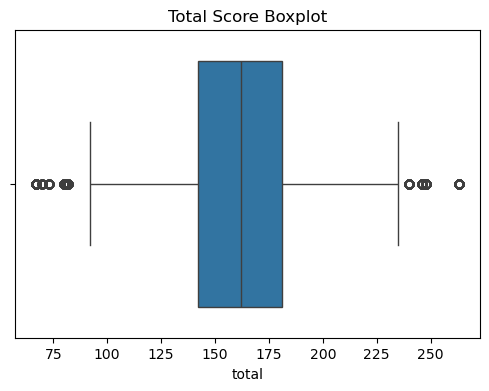

In [54]:
plt.figure(figsize=(6,4))
sns.boxplot(x=df['total'])

plt.title("Total Score Boxplot")


Text(0, 0.5, 'Total Score')

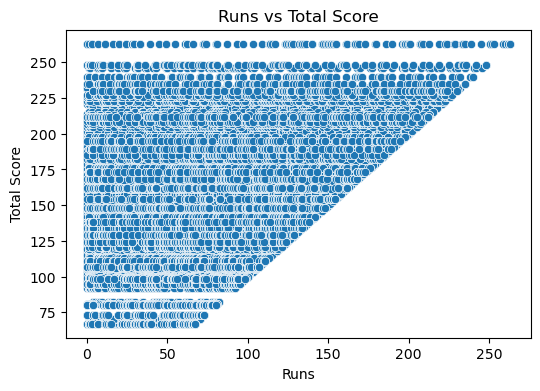

In [55]:
plt.figure(figsize=(6,4))
sns.scatterplot(x=df['runs'], y=df['total'])

plt.title("Runs vs Total Score")

plt.xlabel("Runs")
plt.ylabel("Total Score")

Text(0.5, 1.0, 'Correlation Matrix')

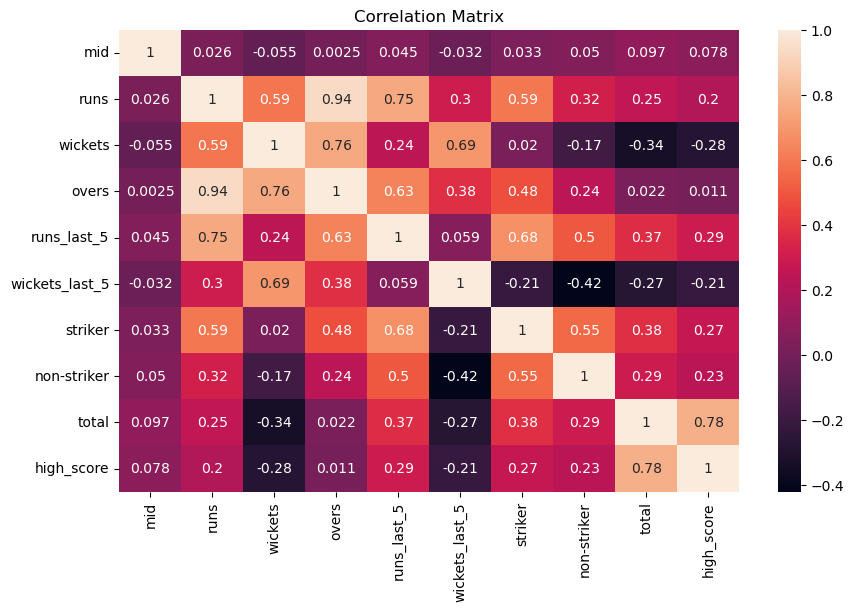

In [56]:
plt.figure(figsize=(10,6))

sns.heatmap(df.corr(numeric_only=True), annot=True)

plt.title("Correlation Matrix")

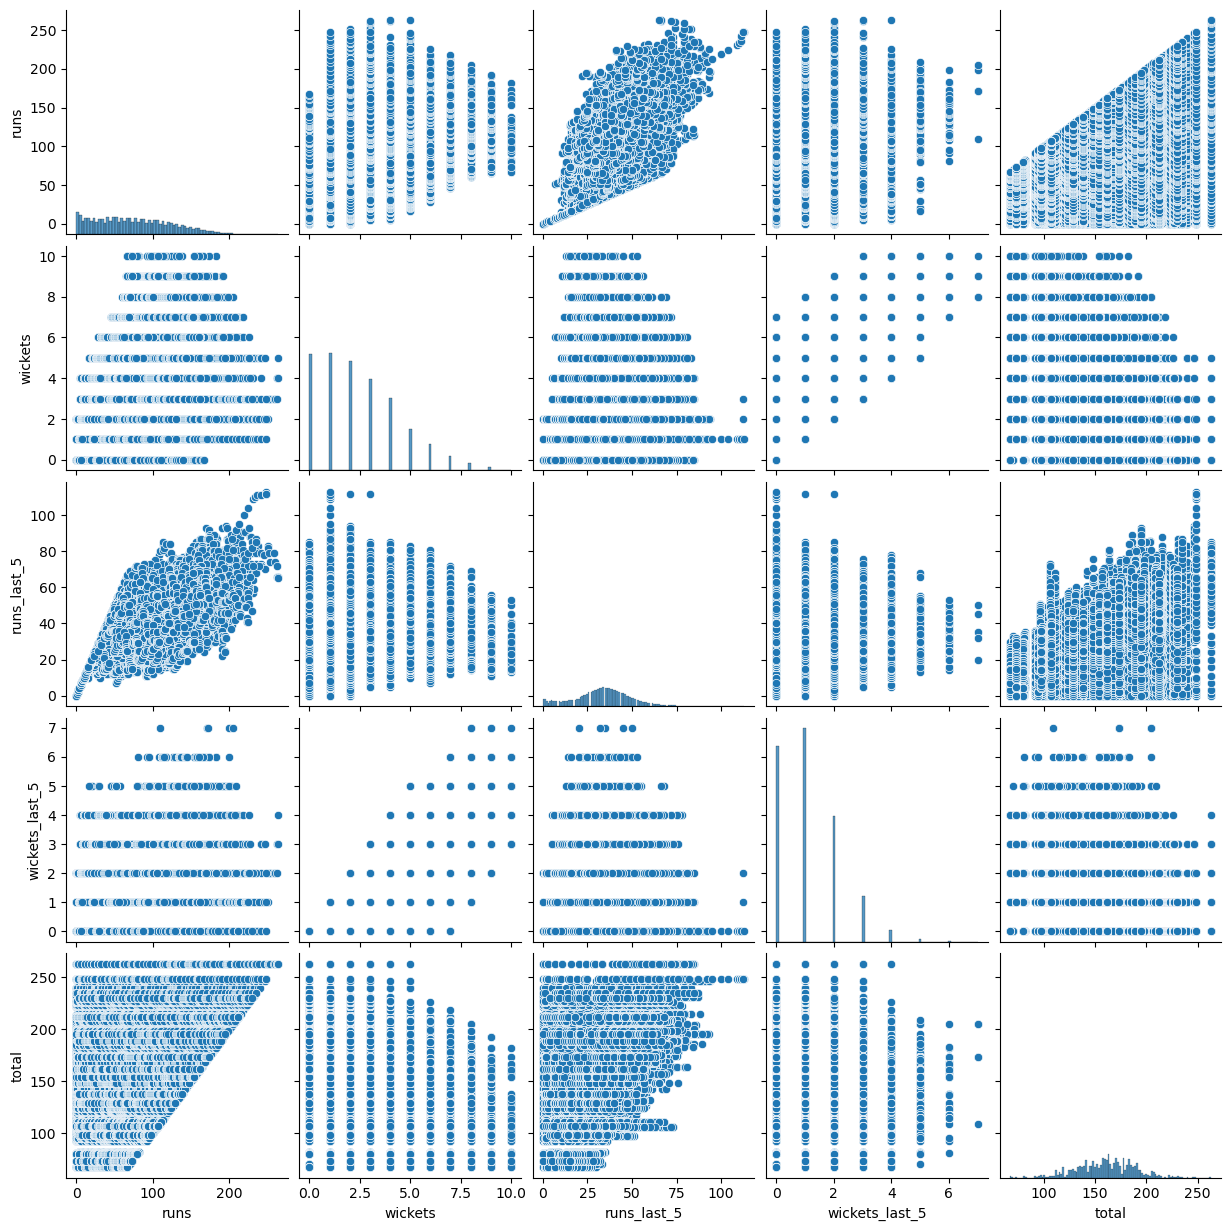

In [57]:
sns.pairplot(df[['runs','wickets','runs_last_5','wickets_last_5','total']])


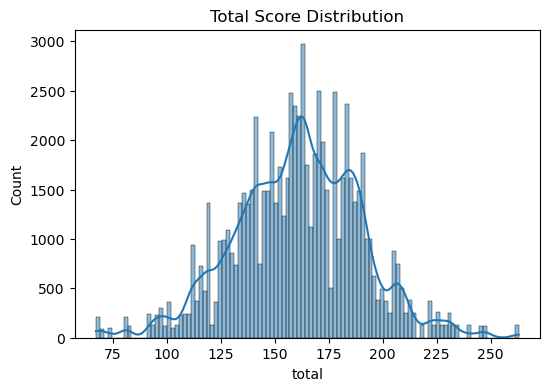

Skewness: -0.06026792976238969


In [58]:
plt.figure(figsize=(6,4))

sns.histplot(df['total'], kde=True)

plt.title("Total Score Distribution")

plt.show()

print("Skewness:", df['total'].skew())